# Phase 4: Modeling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type. Some techniques have specific requirements on the form of data. Therefore, stepping back to the data preparation phase is often needed.

**Input:** `data/preprocessed/fleet_prepared.csv` (20,300 rows × 29 columns)  
**Target:** `failure_type_encoded` — 5-class multi-class classification  

| Class | Label | Count | % |
|---|---|---|---|
| Critical_Overheating | 0 | 344 | 1.69% |
| Mechanical_Stress | 1 | 50 | 0.25% |
| Normal | 2 | 19,554 | 96.33% |
| Thermal_Overload | 3 | 308 | 1.52% |
| Voltage_Sag | 4 | 44 | 0.22% |

**Key Challenges:**
- Severe class imbalance (444:1 majority/minority ratio)
- Business target: ≥ 85% accuracy in predicting component failure
- SMOTE / ADASYN applied only to training folds to avoid evaluation bias

---
## Section 1: Setup & Data Loading

Install and import all required libraries, load the prepared dataset from Phase 3, and define feature matrix `X` and target vector `y`.

In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Standard imports
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalanced learning
from imblearn.over_sampling import ADASYN

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')
%matplotlib inline

print('Phase 4: Modeling')
print(f'Start time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Phase 4: Modeling
Start time: 2026-07-01 03:33:17


In [4]:
# Paths
DATA_PATH = r'E:\Capstone-Project-DEPI-main\data\preprocessed\fleet_prepared.csv'
META_PATH = r'E:\Capstone-Project-DEPI-main\data\preprocessed\preparation_metadata.json'
MODEL_DIR = r'E:\Capstone-Project-DEPI-main\model_weights'

# Load dataset
df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')

# Load metadata from Phase 3
with open(META_PATH, 'r') as f:
    prep_metadata = json.load(f)

label_mapping = prep_metadata['label_mapping']
label_mapping_inv = {v: k for k, v in label_mapping.items()}
class_names = [label_mapping_inv[i] for i in sorted(label_mapping_inv.keys())]

print(f'\nLabel mapping: {label_mapping}')
print(f'Class names (ordered): {class_names}')

df.head()

Dataset loaded: 20300 rows x 29 columns

Label mapping: {'Critical_Overheating': 0, 'Mechanical_Stress': 1, 'Normal': 2, 'Thermal_Overload': 3, 'Voltage_Sag': 4}
Class names (ordered): ['Critical_Overheating', 'Mechanical_Stress', 'Normal', 'Thermal_Overload', 'Voltage_Sag']


,timestamp,speed_kmh,distance_m,soc_pct,battery_voltage_v,battery_temp_c,motor_rpm,motor_temp_c,power_kw,ambient_temp_c,load_kg,car_id,failure_type,power_to_load_ratio,temp_diff_motor_ambient,temp_diff_battery_ambient,voltage_per_soc,speed_x_load,motor_temp_c_roll_mean,motor_temp_c_roll_std,battery_temp_c_roll_mean,battery_temp_c_roll_std,battery_voltage_v_roll_mean,battery_voltage_v_roll_std,power_kw_roll_mean,power_kw_roll_std,hour_of_day,day_of_week,failure_type_encoded
0,2026-01-01 00:00:00,62.9300,0.0000,100.0000,400.0000,25.0000,4472.0000,25.0000,0.0000,25.5000,212.3000,car_1,Normal,0.0000,-0.5000,-0.5000,3.9604,13360.0390,25.0000,0.0000,25.0000,0.0000,400.0000,0.0000,0.0000,0.0000,0,3,2
1,2026-01-01 00:10:00,62.9300,10464.3800,98.6500,397.1400,24.9600,4472.0000,24.1600,6.1000,24.9600,212.3000,car_1,Normal,0.0286,-0.8000,0.0000,3.9853,13360.0390,24.5800,0.5940,24.9800,0.0283,398.5700,2.0223,3.0500,4.3134,0,3,2
2,2026-01-01 00:20:00,53.8300,20952.1000,97.3000,398.1900,25.7300,3809.0000,23.1800,4.9500,25.8500,234.1000,car_1,Normal,0.0211,-2.6700,-0.1200,4.0508,12601.6030,24.1133,0.9109,25.2300,0.4335,398.4433,1.4467,3.6833,3.2413,0,3,2
3,2026-01-01 00:30:00,66.6100,29923.2800,96.2000,396.4500,25.4300,4510.0000,25.8300,5.6900,26.8200,257.2000,car_1,Normal,0.0220,-0.9900,-1.3900,4.0787,17132.0920,24.3900,1.3399,25.3733,0.3881,397.2600,0.8762,5.5800,0.5828,0,3,2
4,2026-01-01 00:40:00,50.7200,41025.7700,94.9300,396.1100,24.9900,3528.0000,22.6400,5.6900,25.1700,307.4000,car_1,Normal,0.0185,-2.5300,-0.1800,4.1292,15591.3280,23.8833,1.7073,25.3833,0.3722,396.9167,1.1158,5.4433,0.4272,0,3,2


In [5]:
# Drop non-feature columns as specified in Phase 3 notes
# 'timestamp' and 'car_id' are identifiers, 'failure_type' is the string version of the target
DROP_COLS = ['timestamp', 'car_id', 'failure_type']
TARGET_COL = 'failure_type_encoded'

# Separate features and target
X = df.drop(columns=DROP_COLS + [TARGET_COL])
y = df[TARGET_COL]

feature_names = X.columns.tolist()

print(f'Feature matrix X: {X.shape}')
print(f'Target vector y:  {y.shape}')
print(f'\nFeatures ({len(feature_names)}):')
for i, f in enumerate(feature_names):
    print(f'  {i+1:>2}. {f}')

print(f'\nTarget class distribution:')
for cls_int, cls_name in label_mapping_inv.items():
    cnt = (y == cls_int).sum()
    pct = cnt / len(y) * 100
    print(f'  {cls_name:>25s} ({cls_int}): {cnt:>6d}  ({pct:5.2f}%)')

Feature matrix X: (20300, 25)
Target vector y:  (20300,)

Features (25):
   1. speed_kmh
   2. distance_m
   3. soc_pct
   4. battery_voltage_v
   5. battery_temp_c
   6. motor_rpm
   7. motor_temp_c
   8. power_kw
   9. ambient_temp_c
  10. load_kg
  11. power_to_load_ratio
  12. temp_diff_motor_ambient
  13. temp_diff_battery_ambient
  14. voltage_per_soc
  15. speed_x_load
  16. motor_temp_c_roll_mean
  17. motor_temp_c_roll_std
  18. battery_temp_c_roll_mean
  19. battery_temp_c_roll_std
  20. battery_voltage_v_roll_mean
  21. battery_voltage_v_roll_std
  22. power_kw_roll_mean
  23. power_kw_roll_std
  24. hour_of_day
  25. day_of_week

Target class distribution:
       Critical_Overheating (0):    344  ( 1.69%)
          Mechanical_Stress (1):     50  ( 0.25%)
                     Normal (2):  19554  (96.33%)
           Thermal_Overload (3):    308  ( 1.52%)
                Voltage_Sag (4):     44  ( 0.22%)


---
## Section 2: Train/Test Split

**Stratified 80/20 split** to ensure each class maintains its proportional representation in both the training and test sets. This is critical given the extreme class imbalance.

In [6]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y  # Preserve class proportions
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

# Verify stratification
print(f'\nClass distribution in splits:')
print(f'{"Class":>25s} | {"Train":>8s} | {"Test":>8s} | {"Train %":>8s} | {"Test %":>8s}')
print('-' * 70)
for cls_int in sorted(label_mapping_inv.keys()):
    cls_name = label_mapping_inv[cls_int]
    train_cnt = (y_train == cls_int).sum()
    test_cnt = (y_test == cls_int).sum()
    train_pct = train_cnt / len(y_train) * 100
    test_pct = test_cnt / len(y_test) * 100
    print(f'{cls_name:>25s} | {train_cnt:>8d} | {test_cnt:>8d} | {train_pct:>7.2f}% | {test_pct:>7.2f}%')

Training set: 16240 samples (80.0%)
Test set:     4060 samples (20.0%)

Class distribution in splits:
                    Class |    Train |     Test |  Train % |   Test %
----------------------------------------------------------------------
     Critical_Overheating |      275 |       69 |    1.69% |    1.70%
        Mechanical_Stress |       40 |       10 |    0.25% |    0.25%
                   Normal |    15643 |     3911 |   96.32% |   96.33%
         Thermal_Overload |      247 |       61 |    1.52% |    1.50%
              Voltage_Sag |       35 |        9 |    0.22% |    0.22%


---
## Section 3: Feature Scaling

Apply `StandardScaler` (zero mean, unit variance) fitted on the **training set only**, then transform both train and test sets. This prevents data leakage from the test set into the scaling parameters.

In [7]:
scaler = StandardScaler()

# Fit on training data ONLY, transform both
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names,
    index=X_test.index
)

print('[OK] StandardScaler fitted on training set, applied to both sets')
print(f'\nTraining set — scaled stats (should be ~0 mean, ~1 std):')
print(f'  Mean range: [{X_train_scaled.mean().min():.6f}, {X_train_scaled.mean().max():.6f}]')
print(f'  Std range:  [{X_train_scaled.std().min():.6f}, {X_train_scaled.std().max():.6f}]')

print(f'\nTest set — scaled stats (slightly off due to distribution shift):')
print(f'  Mean range: [{X_test_scaled.mean().min():.6f}, {X_test_scaled.mean().max():.6f}]')
print(f'  Std range:  [{X_test_scaled.std().min():.6f}, {X_test_scaled.std().max():.6f}]')

[OK] StandardScaler fitted on training set, applied to both sets

Training set — scaled stats (should be ~0 mean, ~1 std):
  Mean range: [-0.000000, 0.000000]
  Std range:  [1.000031, 1.000031]

Test set — scaled stats (slightly off due to distribution shift):
  Mean range: [-0.022864, 0.045175]
  Std range:  [0.897953, 2.087844]


---
## Section 4: Handling Class Imbalance (ADASYN)

**ADASYN** (Adaptive Synthetic Sampling) is used instead of standard SMOTE because it focuses on generating synthetic samples near the decision boundary where the minority class is harder to learn. This is especially important with extreme imbalance (444:1).

**Key principle:** ADASYN is applied **only to the training set** — never to the test set — to prevent evaluation bias.

In [8]:
print('Class distribution BEFORE ADASYN:')
before_counts = y_train.value_counts().sort_index()
for cls_int, cnt in before_counts.items():
    cls_name = label_mapping_inv[cls_int]
    print(f'  {cls_name:>25s} ({cls_int}): {cnt:>6d}')

# Apply ADASYN on training data only
adasyn = ADASYN(random_state=RANDOM_STATE, n_neighbors=5)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train_scaled, y_train)

print(f'\nClass distribution AFTER ADASYN:')
after_counts = pd.Series(y_train_resampled).value_counts().sort_index()
for cls_int, cnt in after_counts.items():
    cls_name = label_mapping_inv[cls_int]
    print(f'  {cls_name:>25s} ({cls_int}): {cnt:>6d}')

print(f'\nTraining samples: {len(y_train)} -> {len(y_train_resampled)} '
      f'(+{len(y_train_resampled) - len(y_train)} synthetic)')

Class distribution BEFORE ADASYN:
       Critical_Overheating (0):    275
          Mechanical_Stress (1):     40
                     Normal (2):  15643
           Thermal_Overload (3):    247
                Voltage_Sag (4):     35

Class distribution AFTER ADASYN:
       Critical_Overheating (0):  15631
          Mechanical_Stress (1):  15652
                     Normal (2):  15643
           Thermal_Overload (3):  15639
                Voltage_Sag (4):  15641

Training samples: 16240 -> 78206 (+61966 synthetic)


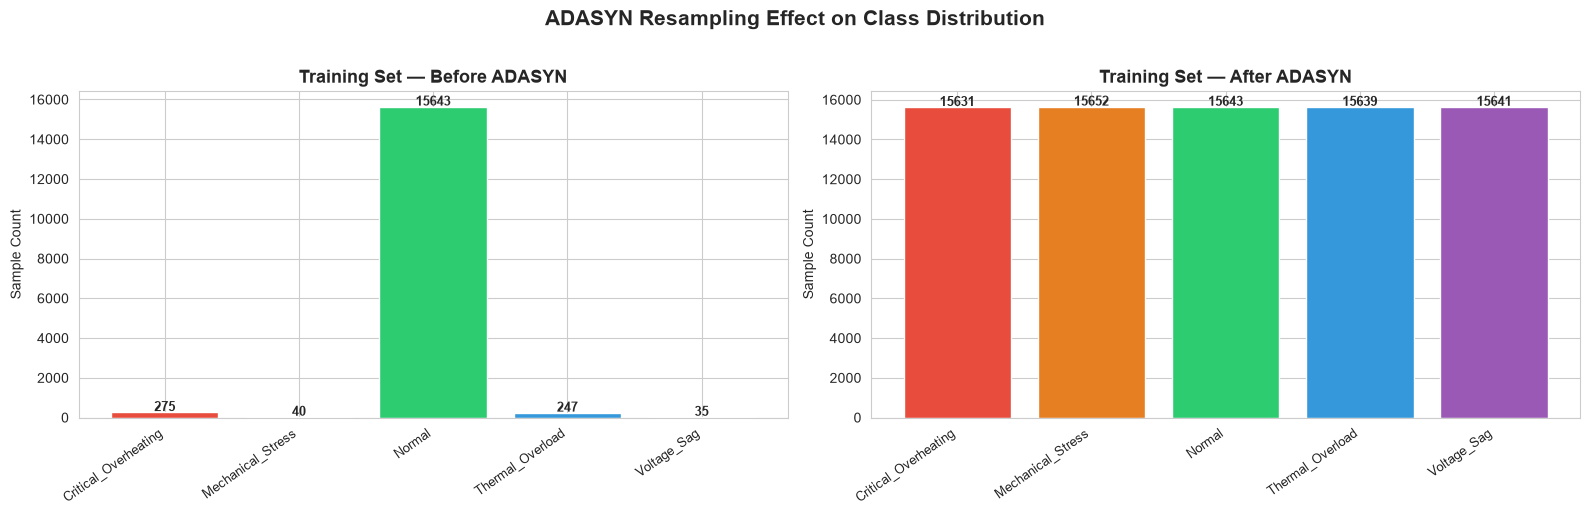

In [9]:
# Visualize class distribution before/after ADASYN
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

# Before
axes[0].bar(range(len(before_counts)), before_counts.values, color=colors, edgecolor='white')
axes[0].set_xticks(range(len(before_counts)))
axes[0].set_xticklabels([label_mapping_inv[i] for i in before_counts.index],
                        rotation=35, ha='right', fontsize=9)
axes[0].set_title('Training Set — Before ADASYN', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sample Count')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=9)

# After
axes[1].bar(range(len(after_counts)), after_counts.values, color=colors, edgecolor='white')
axes[1].set_xticks(range(len(after_counts)))
axes[1].set_xticklabels([label_mapping_inv[i] for i in after_counts.index],
                        rotation=35, ha='right', fontsize=9)
axes[1].set_title('Training Set — After ADASYN', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Sample Count')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=9)

plt.suptitle('ADASYN Resampling Effect on Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 5: Baseline Model — Logistic Regression

Establish a performance lower-bound with a simple Logistic Regression classifier. This serves as the baseline against which all subsequent models are compared.

In [10]:
LogisticRegression?

Init signature:
LogisticRegression(
    penalty='deprecated',
    *,
    C=1.0,
    l1_ratio=0.0,
    dual=False,
    tol=0.0001,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    verbose=0,
    warm_start=False,
    n_jobs=None,
)
Docstring:     
Logistic Regression (aka logit, MaxEnt) classifier.

This class implements regularized logistic regression using a set of available
solvers. **Note that regularization is applied by default**. It can handle both
dense and sparse input `X`. Use C-ordered arrays or CSR matrices containing 64-bit
floats for optimal performance; any other input format will be converted (and
copied).

The solvers 'lbfgs', 'newton-cg', 'newton-cholesky' and 'sag' support only L2
regularization with primal formulation, or no regularization. The 'liblinear'
solver supports both L1 and L2 regularization (but not both, i.e. elastic-net),
with a dual formulation only for the L2 penalt

BASELINE MODEL: Logistic Regression

Baseline Results (on test set):
  Accuracy:    0.9347
  Macro F1:    0.5506
  Weighted F1: 0.9529

Classification Report:
                      precision    recall  f1-score   support

Critical_Overheating     0.2830    0.8696    0.4270        69
   Mechanical_Stress     0.1014    0.7000    0.1772        10
              Normal     0.9997    0.9361    0.9669      3911
    Thermal_Overload     0.7973    0.9672    0.8741        61
         Voltage_Sag     0.1860    0.8889    0.3077         9

            accuracy                         0.9347      4060
           macro avg     0.4735    0.8723    0.5506      4060
        weighted avg     0.9805    0.9347    0.9529      4060



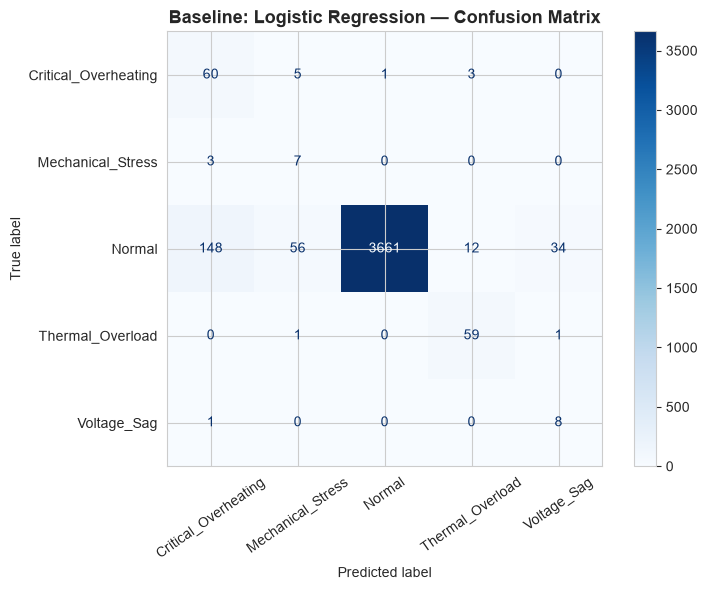

In [11]:
print('='*60)
print('BASELINE MODEL: Logistic Regression')
print('='*60)

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    # multi_class='multinomial',
    solver='lbfgs'
)

baseline_model.fit(X_train_resampled, y_train_resampled)
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1_macro = f1_score(y_test, y_pred_baseline, average='macro')
baseline_f1_weighted = f1_score(y_test, y_pred_baseline, average='weighted')

print(f'\nBaseline Results (on test set):')
print(f'  Accuracy:    {baseline_accuracy:.4f}')
print(f'  Macro F1:    {baseline_f1_macro:.4f}')
print(f'  Weighted F1: {baseline_f1_weighted:.4f}')

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_baseline, target_names=class_names, digits=4))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=35)
ax.set_title('Baseline: Logistic Regression — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6: Model Selection & Training

Train 5 candidate classifiers on the ADASYN-resampled training set. All models are evaluated on the **original** (non-resampled) test set to ensure unbiased performance estimates.

| # | Model | Rationale |
|---|---|---|
| 1 | Random Forest | Robust ensemble; handles class imbalance with `class_weight` |
| 2 | XGBoost | Gradient boosting; excellent for tabular data with imbalance |
| 3 | LightGBM | Fast gradient boosting; built-in `is_unbalance` support |
| 4 | SVC (RBF) | Strong non-linear classifier; works well in scaled feature spaces |
| 5 | k-NN | Instance-based; captures local patterns in feature space |

**Note:** SVR (Support Vector Regression) was considered but is not suitable for this multi-class classification task. SVC (Support Vector Classification) is used instead.

In [12]:
# Define candidate models with reasonable initial hyperparameters
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        is_unbalance=True,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1
    ),
    'SVC (RBF)': SVC(
        kernel='rbf',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        probability=True  # Needed for predict_proba if required later
    ),
    'k-NN': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        n_jobs=-1
    )
}

print(f'Defined {len(models)} candidate models:')
for name in models:
    print(f'  • {name}')

Defined 5 candidate models:
  • Random Forest
  • XGBoost
  • LightGBM
  • SVC (RBF)
  • k-NN


In [13]:
# Train all models and evaluate on test set
results = {}

for name, model in models.items():
    print(f'\n{"="*60}')
    print(f'Training: {name}')
    print(f'{"="*60}')
    
    # Train on ADASYN-resampled training set
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predict on original (non-resampled) test set
    y_pred = model.predict(X_test_scaled)
    
    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'Accuracy': acc,
        'Macro Precision': prec_macro,
        'Macro Recall': rec_macro,
        'Macro F1': f1_macro,
        'Weighted F1': f1_weighted
    }
    
    print(f'  Accuracy:        {acc:.4f}')
    print(f'  Macro Precision: {prec_macro:.4f}')
    print(f'  Macro Recall:    {rec_macro:.4f}')
    print(f'  Macro F1:        {f1_macro:.4f}')
    print(f'  Weighted F1:     {f1_weighted:.4f}')
    
    # Classification Report
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

print(f'\n{"="*60}')
print('All models trained and evaluated.')
print(f'{"="*60}')


Training: Random Forest
  Accuracy:        0.9904
  Macro Precision: 0.8555
  Macro Recall:    0.8778
  Macro F1:        0.8605
  Weighted F1:     0.9908

  Classification Report:
                      precision    recall  f1-score   support

Critical_Overheating     0.7083    0.9855    0.8242        69
   Mechanical_Stress     1.0000    1.0000    1.0000        10
              Normal     0.9979    0.9921    0.9950      3911
    Thermal_Overload     1.0000    0.9672    0.9833        61
         Voltage_Sag     0.5714    0.4444    0.5000         9

            accuracy                         0.9904      4060
           macro avg     0.8555    0.8778    0.8605      4060
        weighted avg     0.9921    0.9904    0.9908      4060


Training: XGBoost
  Accuracy:        0.9929
  Macro Precision: 0.8490
  Macro Recall:    0.9041
  Macro F1:        0.8727
  Weighted F1:     0.9931

  Classification Report:
                      precision    recall  f1-score   support

Critical_Overheating

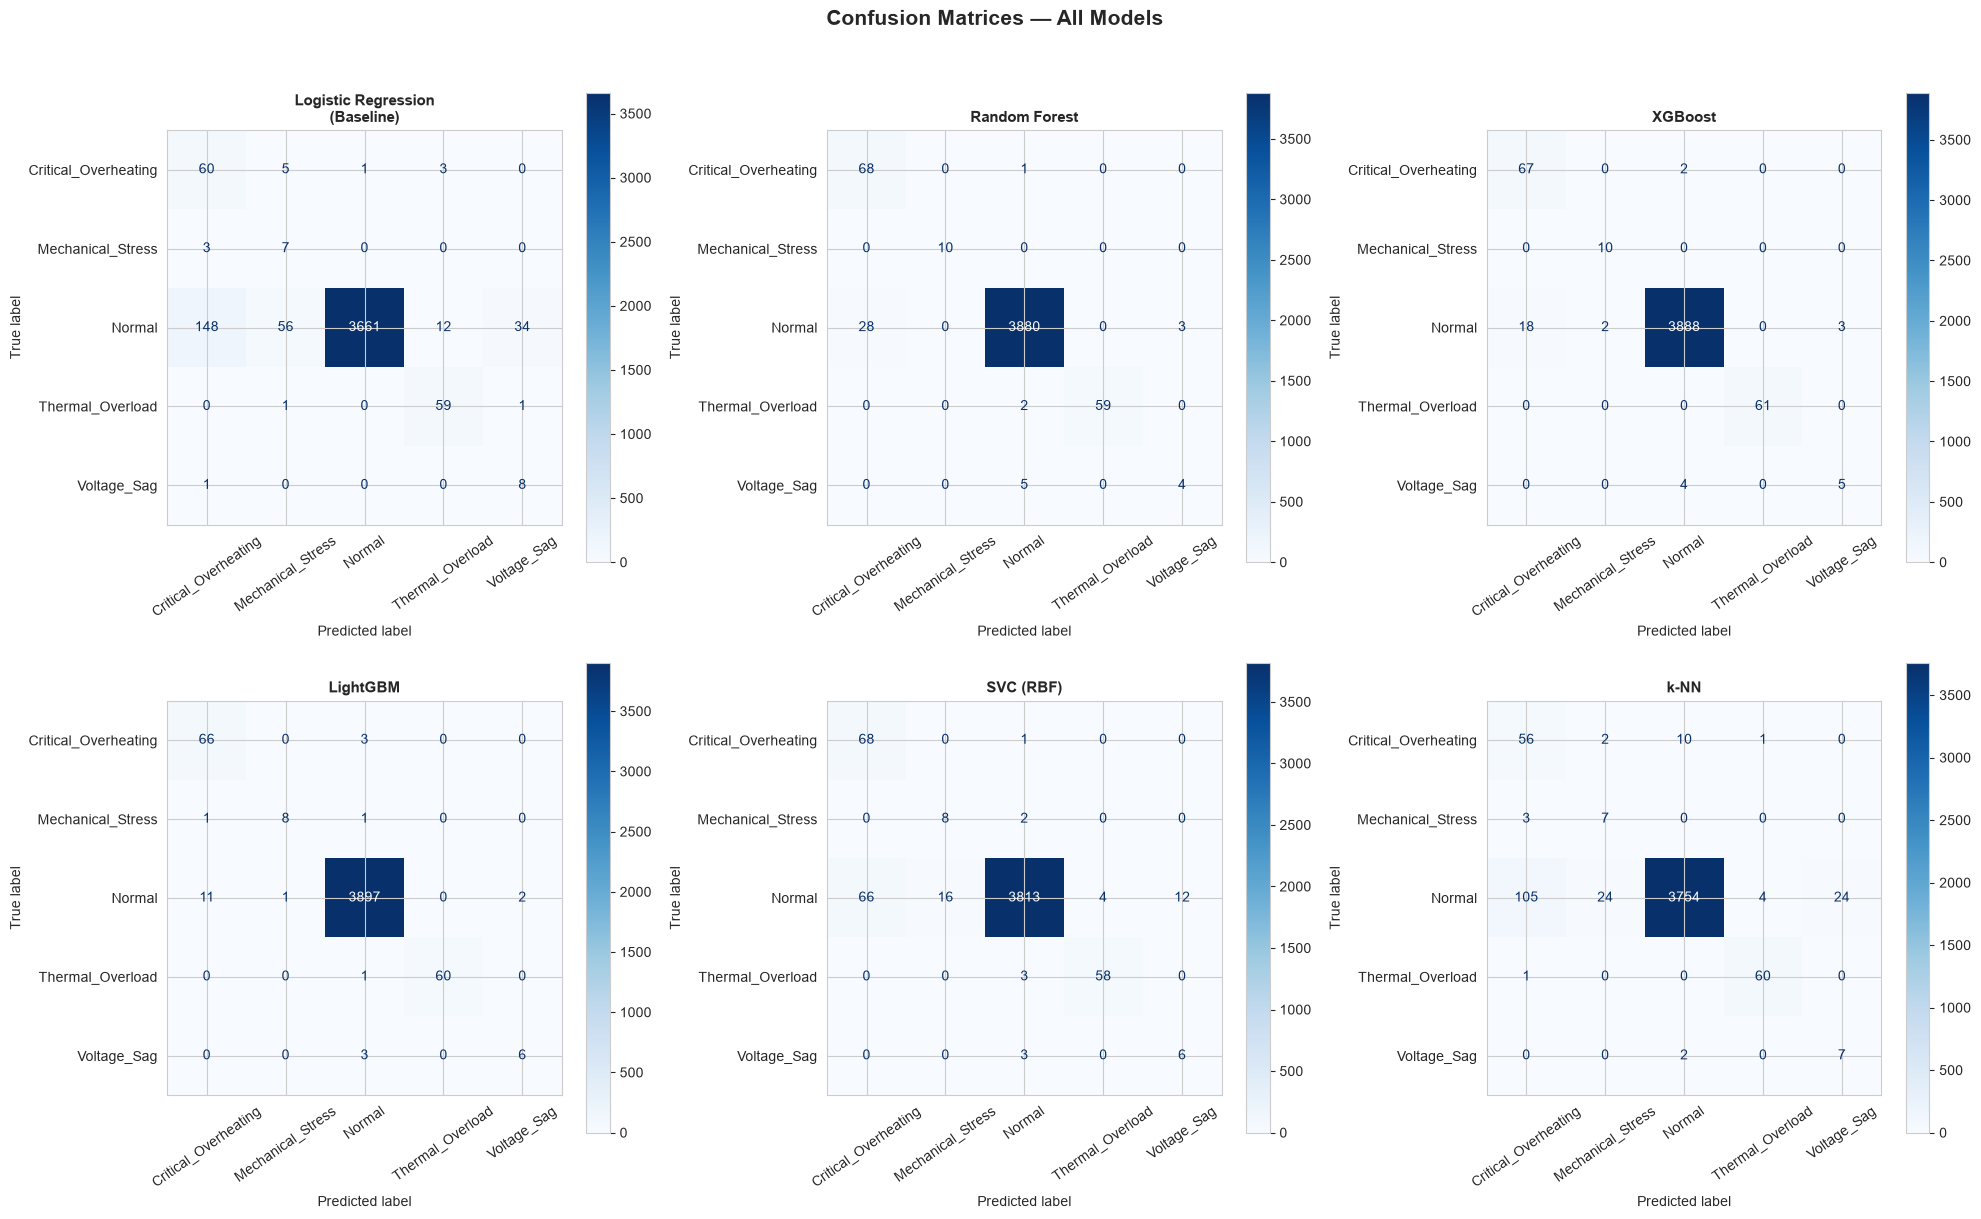

In [14]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Include baseline + 5 candidates
all_models_preds = {
    'Logistic Regression\n(Baseline)': y_pred_baseline,
    **{name: res['y_pred'] for name, res in results.items()}
}

for idx, (name, y_pred) in enumerate(all_models_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', xticks_rotation=35)
    axes[idx].set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 7: Model Comparison

Compare all models (including baseline) across key metrics. The primary selection criterion is **Macro F1** — it equally weights all classes, which is critical when minority failure classes are the most important to detect.

In [15]:
# Build comparison table
metric_cols = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Weighted F1']

comparison_data = {
    'Logistic Regression (Baseline)': {
        'Accuracy': baseline_accuracy,
        'Macro Precision': precision_score(y_test, y_pred_baseline, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_test, y_pred_baseline, average='macro', zero_division=0),
        'Macro F1': baseline_f1_macro,
        'Weighted F1': baseline_f1_weighted
    }
}

for name, res in results.items():
    comparison_data[name] = {m: res[m] for m in metric_cols}

comparison_df = pd.DataFrame(comparison_data).T
comparison_df = comparison_df.sort_values('Macro F1', ascending=False)

print('Model Comparison (sorted by Macro F1):')
print('='*80)
display(comparison_df.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen'))

Model Comparison (sorted by Macro F1):


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
LightGBM,0.9943,0.8966,0.8806,0.8870,0.9944
XGBoost,0.9929,0.8490,0.9041,0.8727,0.9931
Random Forest,0.9904,0.8555,0.8778,0.8605,0.9908
SVC (RBF),0.9736,0.6215,0.8756,0.7028,0.9777
k-NN,0.9567,0.5394,0.8466,0.6169,0.9661
Logistic Regression (Baseline),0.9347,0.4735,0.8723,0.5506,0.9529


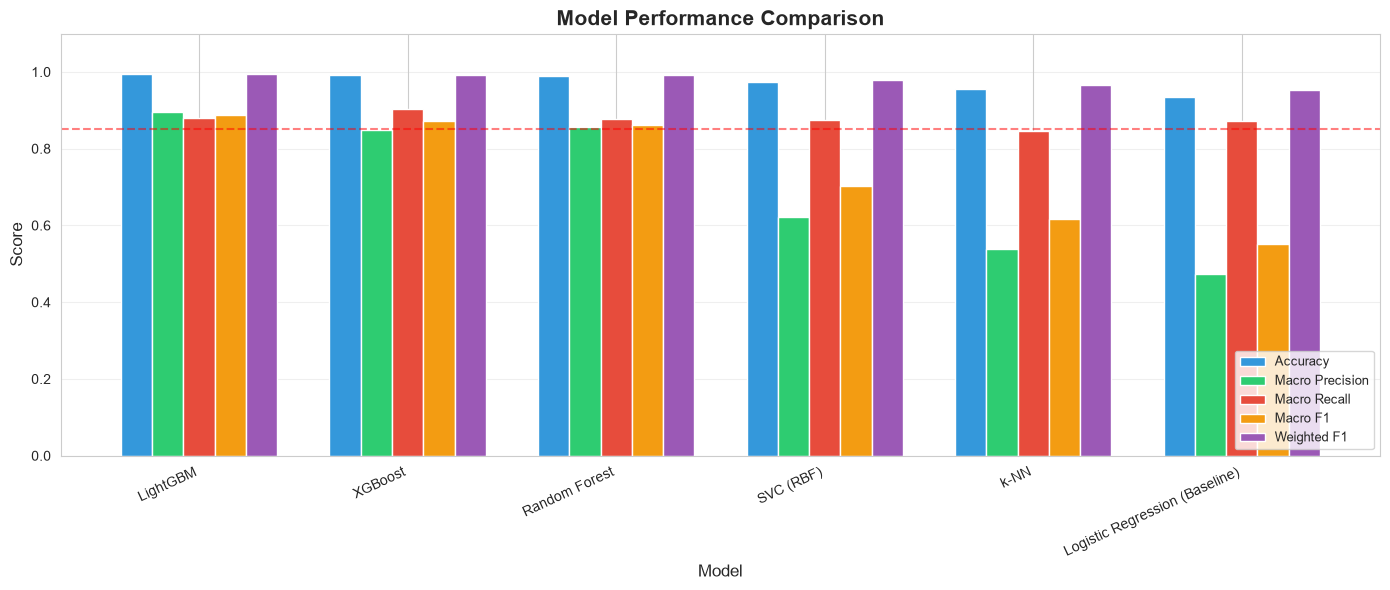

In [16]:
# Grouped bar chart comparing all models
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(comparison_df))
width = 0.15
metric_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, metric in enumerate(metric_cols):
    ax.bar(x + i * width, comparison_df[metric], width,
           label=metric, color=metric_colors[i], edgecolor='white')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(comparison_df.index, rotation=25, ha='right', fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Business Target (85%)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Select best model based on Macro F1
best_model_name = comparison_df['Macro F1'].idxmax()
best_macro_f1 = comparison_df.loc[best_model_name, 'Macro F1']
best_accuracy = comparison_df.loc[best_model_name, 'Accuracy']

print(f'Best model selected: {best_model_name}')
print(f'  Macro F1:  {best_macro_f1:.4f}')
print(f'  Accuracy:  {best_accuracy:.4f}')

# Get the model object
if best_model_name == 'Logistic Regression (Baseline)':
    best_model = baseline_model
else:
    best_model = results[best_model_name]['model']

Best model selected: LightGBM
  Macro F1:  0.8870
  Accuracy:  0.9943


---
## Section 8: Hyperparameter Tuning (GridSearchCV + K-Fold)

Apply `GridSearchCV` with **Stratified 5-Fold Cross-Validation** to the best-performing model. The tuning optimizes for **Macro F1** to ensure all classes, especially minority failure types, are well-represented in the objective.

**Note:** Grid search is performed on the ADASYN-resampled training data. The final model is retrained with the best hyperparameters and evaluated on the held-out test set.

In [18]:
# Define parameter grids for each possible best model
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': ['balanced', 'balanced_subsample']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [-1, 10, 20],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 50, 70],
        'min_child_samples': [10, 20, 30]
    },
    'SVC (RBF)': {
        'C': [0.1, 1.0, 10.0],
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'class_weight': ['balanced']
    },
    'k-NN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'Logistic Regression (Baseline)': {
        'C': [0.01, 0.1, 1.0, 10.0],
        'solver': ['lbfgs', 'saga'],
        'max_iter': [1000, 2000]
    }
}

print(f'Parameter grid for best model "{best_model_name}":')
selected_grid = param_grids.get(best_model_name, {})
for param, values in selected_grid.items():
    print(f'  {param}: {values}')

total_combos = 1
for v in selected_grid.values():
    total_combos *= len(v)
print(f'\nTotal combinations: {total_combos}')
print(f'With 5-fold CV: {total_combos * 5} fits')

Parameter grid for best model "LightGBM":
  n_estimators: [100, 200, 300]
  max_depth: [-1, 10, 20]
  learning_rate: [0.01, 0.05, 0.1]
  num_leaves: [31, 50, 70]
  min_child_samples: [10, 20, 30]

Total combinations: 243
With 5-fold CV: 1215 fits


In [19]:
# Stratified K-Fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# GridSearchCV
print(f'Running GridSearchCV for: {best_model_name}')
print(f'Scoring: macro F1 | CV: Stratified 5-Fold')
print(f'This may take a few minutes...\n')

grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=selected_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True  # Retrain on all training data with best params
)

grid_search.fit(X_train_resampled, y_train_resampled)

print(f'\n{"="*60}')
print(f'GridSearchCV Results')
print(f'{"="*60}')
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV Macro F1: {grid_search.best_score_:.4f}')

Running GridSearchCV for: LightGBM
Scoring: macro F1 | CV: Stratified 5-Fold
This may take a few minutes...

Fitting 5 folds for each of 243 candidates, totalling 1215 fits

GridSearchCV Results
Best parameters: {'learning_rate': 0.05, 'max_depth': 10, 'min_child_samples': 30, 'n_estimators': 300, 'num_leaves': 50}
Best CV Macro F1: 0.9988


In [20]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values('rank_test_score').head(10)

display_cols = ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']
print('Top 10 hyperparameter configurations:')
display(cv_results_sorted[display_cols].reset_index(drop=True))

Top 10 hyperparameter configurations:


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.9988,0.0002,"{'learning_rate': 0.05, 'max_depth': 10, 'min_..."
1,2,0.9988,0.0003,"{'learning_rate': 0.05, 'max_depth': 10, 'min_..."
2,3,0.9988,0.0002,"{'learning_rate': 0.05, 'max_depth': 10, 'min_..."
3,4,0.9988,0.0002,"{'learning_rate': 0.1, 'max_depth': -1, 'min_c..."
4,4,0.9988,0.0002,"{'learning_rate': 0.1, 'max_depth': 20, 'min_c..."
5,6,0.9988,0.0003,"{'learning_rate': 0.1, 'max_depth': -1, 'min_c..."
6,7,0.9988,0.0002,"{'learning_rate': 0.05, 'max_depth': -1, 'min_..."
7,8,0.9988,0.0003,"{'learning_rate': 0.1, 'max_depth': 10, 'min_c..."
8,9,0.9988,0.0003,"{'learning_rate': 0.1, 'max_depth': 10, 'min_c..."
9,10,0.9988,0.0002,"{'learning_rate': 0.1, 'max_depth': -1, 'min_c..."


Tuned Model Evaluation (Test Set):
  Model:       LightGBM
  Accuracy:    0.9941
  Macro F1:    0.8646
  Weighted F1: 0.9941

Improvement over untuned:
  Accuracy:  -0.0002
  Macro F1:  -0.0223

Classification Report (Tuned):
                      precision    recall  f1-score   support

Critical_Overheating     0.8571    0.9565    0.9041        69
   Mechanical_Stress     0.8889    0.8000    0.8421        10
              Normal     0.9977    0.9964    0.9971      3911
    Thermal_Overload     1.0000    0.9836    0.9917        61
         Voltage_Sag     0.6250    0.5556    0.5882         9

            accuracy                         0.9941      4060
           macro avg     0.8737    0.8584    0.8646      4060
        weighted avg     0.9942    0.9941    0.9941      4060



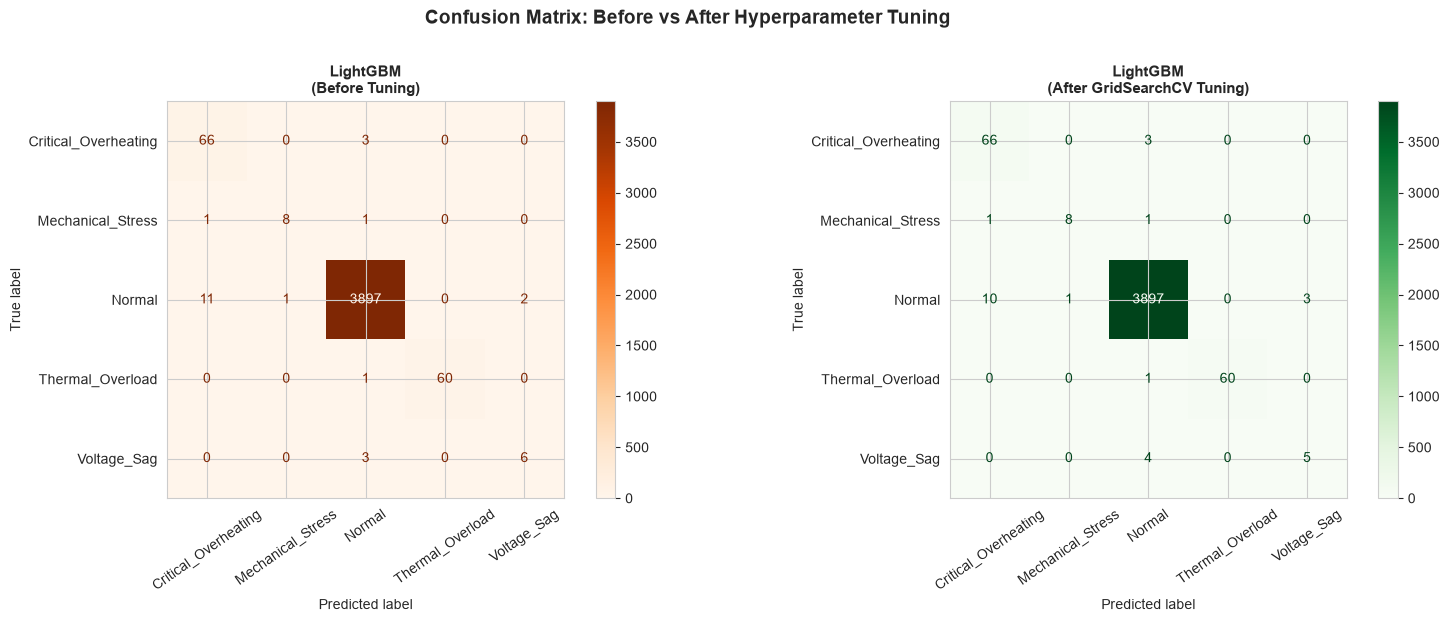

In [21]:
# Evaluate tuned model on test set
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_f1_macro = f1_score(y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_f1_weighted = f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)

print(f'Tuned Model Evaluation (Test Set):')
print(f'  Model:       {best_model_name}')
print(f'  Accuracy:    {tuned_accuracy:.4f}')
print(f'  Macro F1:    {tuned_f1_macro:.4f}')
print(f'  Weighted F1: {tuned_f1_weighted:.4f}')

print(f'\nImprovement over untuned:')
print(f'  Accuracy:  {tuned_accuracy - best_accuracy:+.4f}')
print(f'  Macro F1:  {tuned_f1_macro - best_macro_f1:+.4f}')

print(f'\nClassification Report (Tuned):')
print(classification_report(y_test, y_pred_tuned, target_names=class_names, digits=4))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before tuning
if best_model_name == 'Logistic Regression (Baseline)':
    y_pred_before = y_pred_baseline
else:
    y_pred_before = results[best_model_name]['y_pred']

cm_before = confusion_matrix(y_test, y_pred_before)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_before, display_labels=class_names)
disp1.plot(ax=axes[0], cmap='Oranges', values_format='d', xticks_rotation=35)
axes[0].set_title(f'{best_model_name}\n(Before Tuning)', fontsize=11, fontweight='bold')

# After tuning
cm_after = confusion_matrix(y_test, y_pred_tuned)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_after, display_labels=class_names)
disp2.plot(ax=axes[1], cmap='Greens', values_format='d', xticks_rotation=35)
axes[1].set_title(f'{best_model_name}\n(After GridSearchCV Tuning)', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix: Before vs After Hyperparameter Tuning',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Phase 4 Summary
print('='*60)
print('PHASE 4 COMPLETE — MODELING SUMMARY')
print('='*60)
print(f'  Models trained:     {len(models) + 1} (baseline + {len(models)} candidates)')
print(f'  Best model:         {best_model_name}')
print(f'  Tuning method:      GridSearchCV (Stratified 5-Fold CV)')
print(f'  Best parameters:    {grid_search.best_params_}')
print(f'  Best CV Macro F1:   {grid_search.best_score_:.4f}')
print(f'  Test Accuracy:      {tuned_accuracy:.4f}')
print(f'  Test Macro F1:      {tuned_f1_macro:.4f}')
print(f'  Test Weighted F1:   {tuned_f1_weighted:.4f}')
print(f'  Business target:    {"MET ✓" if tuned_accuracy >= 0.85 else "NOT MET ✗"} (≥85% accuracy)')
print(f'  Resampling:         ADASYN (training set only)')
print(f'  Finish time:        {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('='*60)
print('\nNext: Phase 5 — Evaluation (detailed evaluation, model export, deployment prep)')

PHASE 4 COMPLETE — MODELING SUMMARY
  Models trained:     6 (baseline + 5 candidates)
  Best model:         LightGBM
  Tuning method:      GridSearchCV (Stratified 5-Fold CV)
  Best parameters:    {'learning_rate': 0.05, 'max_depth': 10, 'min_child_samples': 30, 'n_estimators': 300, 'num_leaves': 50}
  Best CV Macro F1:   0.9988
  Test Accuracy:      0.9941
  Test Macro F1:      0.8646
  Test Weighted F1:   0.9941
  Business target:    MET ✓ (≥85% accuracy)
  Resampling:         ADASYN (training set only)
  Finish time:        2026-07-01 04:18:18

Next: Phase 5 — Evaluation (detailed evaluation, model export, deployment prep)
